In [1]:
import anndata as ad
import os
import pandas as pd
import matplotlib.pyplot as plt

## Download results

In [2]:
def dict_to_pd(d):
    rows = []

    for outer_key, inner in d.items():
        row = {
            "dataset_id": inner["dataset_id"],
            "method_id": inner["method_id"],
        }
        
        # Use values from "d" as column names
        for col_name, value in zip(inner["metric_ids"], inner["metric_values"]):
            row[col_name] = value
            
        rows.append(row)
    
    df = pd.DataFrame(rows, index=d.keys())
    return df

In [3]:
methods_path = '../../data/benchmark/results/metrics/methods/'

In [4]:
os.listdir(methods_path + 'nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable/stability')

['seed_1', 'seed_2', 'seed_3', 'seed_4', 'seed_0']

In [5]:
file_name_err = 'mean_rowwise_error.h5ad'
file_name_corr = 'mean_rowwise_correlation.h5ad'

In [6]:
methods_err = {}
methods_corr = {}
for item in os.listdir(methods_path):
    if 'mol_emb_subsample' in item:
        stability_path = methods_path + item + '/stability'
        for seed in os.listdir(stability_path):
            
            err = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_err}').uns
            corr = ad.read_h5ad(f'{stability_path}/{seed}/{file_name_corr}').uns
            methods_err[item + '_' + seed] = err
            methods_corr[item + '_' + seed] = corr

In [7]:
df_method_err = dict_to_pd(methods_err)

In [8]:
df_method_corr = dict_to_pd(methods_corr)

In [9]:
df_method_err['method_name'] = df_method_err.index.str.split('_seed_').str[0]
df_method_err['seed'] = df_method_err.index.str.split('_seed_').str[1].astype(int)

In [10]:
df_method_corr['method_name'] = df_method_corr.index.str.split('_seed_').str[0]
df_method_corr['seed'] = df_method_corr.index.str.split('_seed_').str[1].astype(int)

## Mean rowwise error

### Methods

In [11]:
df_method_err.sort_values(by="mean_rowwise_rmse")

,dataset_id,method_id,mean_rowwise_rmse,mean_rowwise_mae,method_name,seed
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_concat_dense_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_con...,0.771154,0.560883,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.771371,0.558549,nn_retraining_with_pseudolabels_mol_emb_subsam...,1
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_fixed_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_fixed,0.771421,0.560991,nn_retraining_with_pseudolabels_mol_emb_subsam...,1
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_dense_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.771755,0.557349,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.771808,0.558389,nn_retraining_with_pseudolabels_mol_emb_subsam...,2
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.771888,0.559362,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_concat_dense_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_co...,0.772528,0.558035,nn_retraining_with_pseudolabels_mol_emb_subsam...,1
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_fixed_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_fixed,0.772942,0.562111,nn_retraining_with_pseudolabels_mol_emb_subsam...,3
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_concat_dense_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_con...,0.772965,0.561934,nn_retraining_with_pseudolabels_mol_emb_subsam...,3
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_concat_dense_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_con...,0.772966,0.562632,nn_retraining_with_pseudolabels_mol_emb_subsam...,1


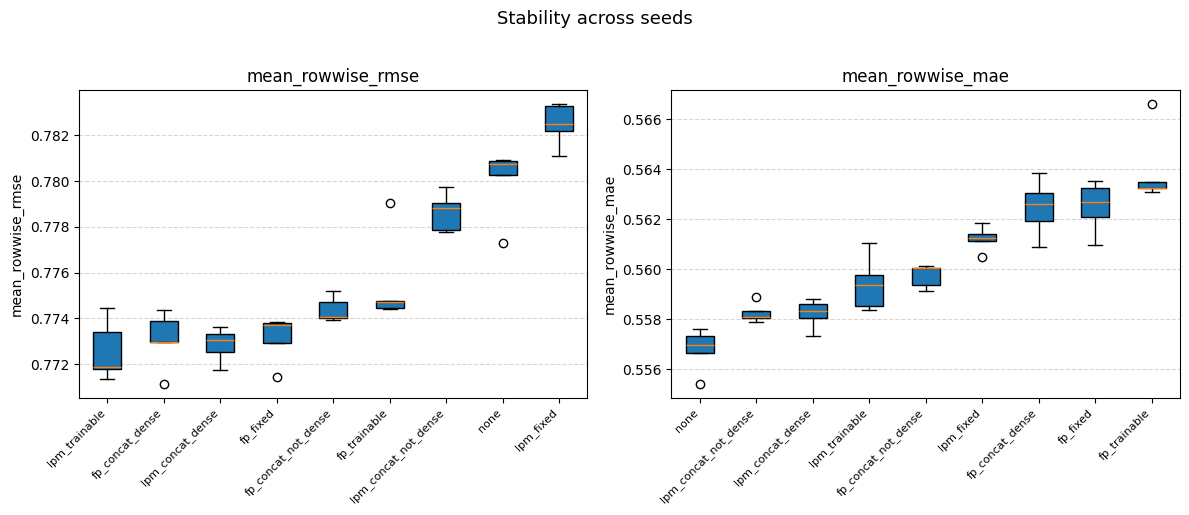

In [12]:
metrics = ["mean_rowwise_rmse", "mean_rowwise_mae"]
fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
for ax, metric in zip(axes, metrics):
    # collect values per method, ordered by median
    methods_ordered = (
        df_method_err.groupby("method_name")[metric]
        .median()
        .sort_values()
        .index.tolist()
    )
    data_per_method = [
        df_method_err.loc[df_method_err["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    bp = ax.boxplot(data_per_method, patch_artist=True, vert=True)
    ax.set_xticks(range(1, len(methods_ordered) + 1))
    ax.set_xticklabels(
        # strip the long common prefix for readability
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
fig.suptitle("Stability across seeds", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Mean rowwise correlation

### Methods

In [13]:
df_method_corr.sort_values(by="mean_rowwise_pearson", ascending=False)
#df_method_corr.sort_values(by="mean_rowwise_spearman", ascending=False)

,dataset_id,method_id,mean_rowwise_pearson,mean_rowwise_spearman,mean_rowwise_cosine,method_name,seed
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.494524,0.464688,0.497521,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.494247,0.464443,0.497263,nn_retraining_with_pseudolabels_mol_emb_subsam...,4
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.494070,0.464636,0.497025,nn_retraining_with_pseudolabels_mol_emb_subsam...,2
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.493912,0.463809,0.496961,nn_retraining_with_pseudolabels_mol_emb_subsam...,1
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_0,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.493030,0.462767,0.495960,nn_retraining_with_pseudolabels_mol_emb_subsam...,0
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_2,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.492930,0.462927,0.495848,nn_retraining_with_pseudolabels_mol_emb_subsam...,2
nn_retraining_with_pseudolabels_mol_emb_subsample_lpm_trainable_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_lpm_tr...,0.492842,0.462902,0.495819,nn_retraining_with_pseudolabels_mol_emb_subsam...,3
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_3,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.492648,0.462214,0.495599,nn_retraining_with_pseudolabels_mol_emb_subsam...,3
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_4,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.492210,0.462128,0.495175,nn_retraining_with_pseudolabels_mol_emb_subsam...,4
nn_retraining_with_pseudolabels_mol_emb_subsample_fp_trainable_seed_1,neurips-2023-data,nn_retraining_with_pseudolabels_mol_emb_fp_tra...,0.491106,0.460547,0.494079,nn_retraining_with_pseudolabels_mol_emb_subsam...,1


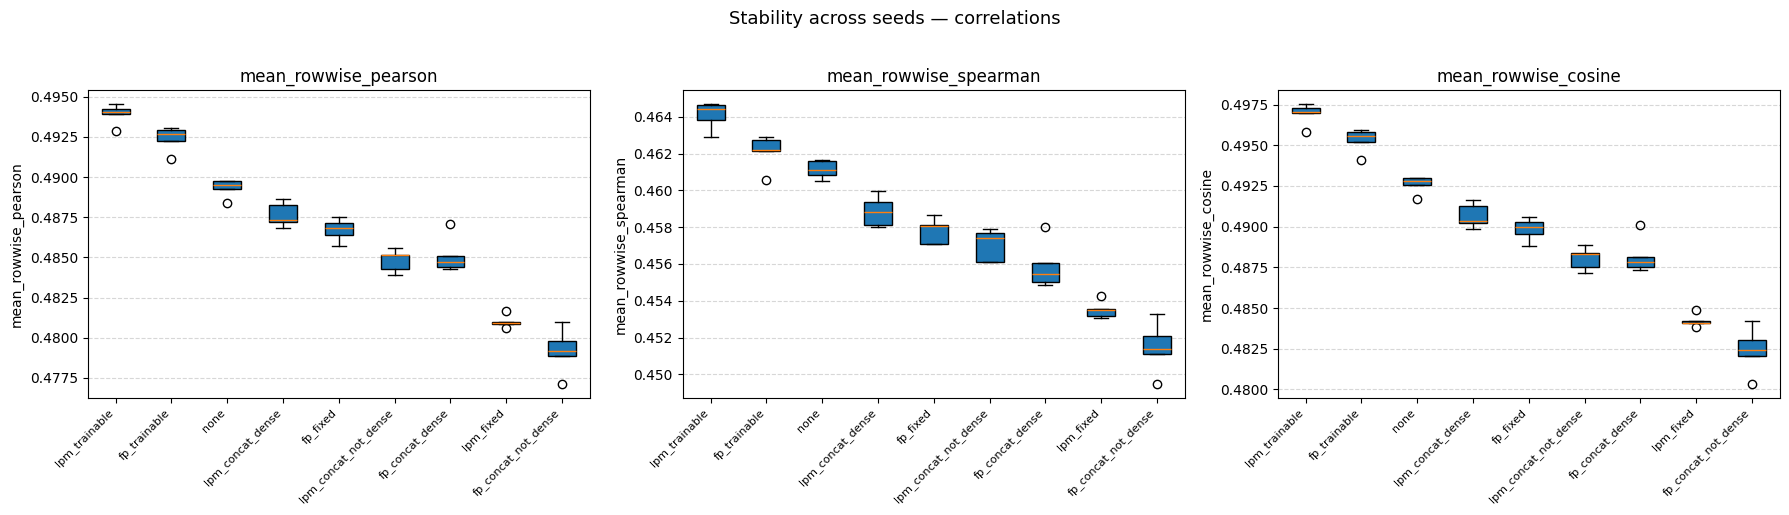

In [14]:
corr_metrics = ["mean_rowwise_pearson", "mean_rowwise_spearman", "mean_rowwise_cosine"]
fig, axes = plt.subplots(1, len(corr_metrics), figsize=(6 * len(corr_metrics), 5))
for ax, metric in zip(axes, corr_metrics):
    # higher correlation is better → sort descending
    methods_ordered = (
        df_method_corr.groupby("method_name")[metric]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    data_per_method = [
        df_method_corr.loc[df_method_corr["method_name"] == m, metric].values
        for m in methods_ordered
    ]
    bp = ax.boxplot(data_per_method, patch_artist=True, vert=True)
    ax.set_xticks(range(1, len(methods_ordered) + 1))
    ax.set_xticklabels(
        [m.replace("nn_retraining_with_pseudolabels_mol_emb_subsample_", "") for m in methods_ordered],
        rotation=45, ha="right", fontsize=8,
    )
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
fig.suptitle("Stability across seeds — correlations", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()